In [1]:
import os
import time
import datetime
import argparse
import warnings


import torch.optim as optim
from torch.optim.lr_scheduler import StepLR


import torch.optim as optim
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.model_selection import ShuffleSplit

import sys 
sys.path.append('/home/peijiazheng/software/scTranslator-main/code/model') 
from performer_enc_dec import *
from utils import *
import anndata as ad

/home/peijiazheng/miniconda3/envs/spatial/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
model = scPerformerEncDec(
    dim=128,
    translator_depth=2,
    initial_dropout=0.1,
    enc_depth=2,
    enc_heads=8,
    enc_max_seq_len=20000,
    dec_depth=2,
    dec_heads=8,
    dec_max_seq_len=1000
    )

In [3]:
model = torch.load('/mnt/vdd/pjz/checkpoint/scTranslator_10K.pt')

In [4]:
device = 'cuda:1' if torch.cuda.is_available() else 'cpu'
model.to(device)

scPerformerEncDec(
  (enc): scPerformerLM(
    (to_vector): Linear(in_features=1, out_features=128, bias=True)
    (pos_emb): Embedding(85500, 128, padding_idx=0)
    (layer_pos_emb): Always()
    (dropout): Dropout(p=0.0, inplace=False)
    (performer): Performer(
      (net): SequentialSequence(
        (layers): ModuleList(
          (0-1): 2 x ModuleList(
            (0): PreLayerNorm(
              (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
              (fn): SelfAttention(
                (fast_attention): FastAttention(
                  (kernel_fn): ReLU()
                )
                (to_q): Linear(in_features=128, out_features=512, bias=True)
                (to_k): Linear(in_features=128, out_features=512, bias=True)
                (to_v): Linear(in_features=128, out_features=512, bias=True)
                (to_out): Linear(in_features=512, out_features=128, bias=True)
                (dropout): Dropout(p=0.0, inplace=False)
              )
        

In [5]:
scRNA_adata = sc.read_h5ad('/mnt/vdd/pjz/checkpoint/scRNA_adata_mapped.h5ad')
scP_adata = sc.read_h5ad('/mnt/vdd/pjz/checkpoint/scP_adata_mapped.h5ad')

scP_adata = scP_adata[scRNA_adata.obs.index]

In [6]:
train_index, test_index = next(ShuffleSplit(n_splits=1,test_size=0.3).split(scRNA_adata.obs.index))

In [7]:
train_rna = scRNA_adata[train_index]
test_rna = scRNA_adata[test_index]
train_protein = scP_adata[train_index]
test_protein = scP_adata[test_index]

In [8]:
my_trainset = fix_SCDataset(train_rna, train_protein, 20000, 1000)
my_testset = fix_SCDataset(test_rna, test_protein, 20000, 1000)

In [9]:
train_kwargs = {'batch_size': 32}
test_kwargs = {'batch_size': 32}
cuda_kwargs = {'num_workers': 32,
                'shuffle': False,
                'prefetch_factor': 2,
                'pin_memory': True}
train_kwargs.update(cuda_kwargs)
test_kwargs.update(cuda_kwargs)

In [10]:
train_loader = torch.utils.data.DataLoader(my_trainset, **train_kwargs, drop_last=True)
test_loader = torch.utils.data.DataLoader(my_testset, **test_kwargs, drop_last=True)

In [11]:
# 冻结所有参数
for param in model.parameters():
    param.requires_grad = False

# 解冻 所有 self-attention 和 to_out
for name, param in model.named_parameters():
    if ("to_q" in name.lower()) or ("to_k" in name.lower()) or ("to_v" in name.lower()) or ("to_out" in name.lower()):
        param.requires_grad = True
        print(f"Unfroze: {name}")

Unfroze: enc.to_vector.weight
Unfroze: enc.to_vector.bias
Unfroze: enc.performer.net.layers.0.0.fn.to_q.weight
Unfroze: enc.performer.net.layers.0.0.fn.to_q.bias
Unfroze: enc.performer.net.layers.0.0.fn.to_k.weight
Unfroze: enc.performer.net.layers.0.0.fn.to_k.bias
Unfroze: enc.performer.net.layers.0.0.fn.to_v.weight
Unfroze: enc.performer.net.layers.0.0.fn.to_v.bias
Unfroze: enc.performer.net.layers.0.0.fn.to_out.weight
Unfroze: enc.performer.net.layers.0.0.fn.to_out.bias
Unfroze: enc.performer.net.layers.1.0.fn.to_q.weight
Unfroze: enc.performer.net.layers.1.0.fn.to_q.bias
Unfroze: enc.performer.net.layers.1.0.fn.to_k.weight
Unfroze: enc.performer.net.layers.1.0.fn.to_k.bias
Unfroze: enc.performer.net.layers.1.0.fn.to_v.weight
Unfroze: enc.performer.net.layers.1.0.fn.to_v.bias
Unfroze: enc.performer.net.layers.1.0.fn.to_out.weight
Unfroze: enc.performer.net.layers.1.0.fn.to_out.bias
Unfroze: enc.to_out.weight
Unfroze: enc.to_out.bias
Unfroze: dec.to_vector.weight
Unfroze: dec.to_vect

In [12]:
optimizer = optim.Adam(model.parameters(), lr=0.001, amsgrad=True)
scheduler = StepLR(optimizer, step_size=2000, gamma=1)

In [13]:
def setup_seed(seed):
    #--- Fix random seed ---#
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

setup_seed(42)

In [14]:
from scipy.stats import pearsonr

def cal_corr(y_hat, y):
    correlations = []

    for i in range(y_hat.shape[1]):
        r, _ = pearsonr(y_hat[:, i], y[:, i])
        correlations.append(r)

    correlations = np.array(correlations)

    return correlations.mean(), correlations.max(), correlations.min()

In [15]:
def train(model, device, train_loader, optimizer, epoch):
    model.train()
    loss2 = nn.CosineSimilarity(dim=0, eps=1e-8)
    train_loss = 0
    train_ccc = 0
    y_hat_all = []
    y_all = []
    for batch_idx, (x, y) in enumerate(train_loader):
        #--- Extract Feature ---#
        RNA_geneID = torch.tensor(x[:,1].tolist()).long().to(device)
        Protein_geneID = torch.tensor(y[:,1].tolist()).long().to(device)
        rna_mask = torch.tensor(x[:,2].tolist()).bool().to(device)
        pro_mask = torch.tensor(y[:,2].tolist()).bool().to(device)
        x = torch.tensor(x[:,0].tolist(), dtype=torch.float32).to(device)
        y = torch.tensor(y[:,0].tolist(), dtype=torch.float32).to(device)

        #--- Prediction ---#
        optimizer.zero_grad()
        _, y_hat = model(x, RNA_geneID, Protein_geneID, enc_mask=rna_mask, dec_mask=pro_mask)

        #--- Compute Performance Metric ---#
        y_hat = torch.squeeze(y_hat)
        y_hat = torch.where(torch.isnan(y), torch.full_like(y_hat, 0), y_hat)
        y = torch.where(torch.isnan(y), torch.full_like(y, 0), y)

        loss = F.mse_loss(y_hat[pro_mask], y[pro_mask])
        train_loss += loss.item()
        
        train_ccc += loss2(y_hat[pro_mask], y[pro_mask]).item()
        loss.backward()
        optimizer.step()

        if device == 'cpu':
            y_hat_all.extend(y_hat[pro_mask].view(y_hat.shape[0], -1).numpy().tolist())
            y_all.extend(y[pro_mask].view(y_hat.shape[0], -1).numpy().tolist())
        else:
            y_hat_all.extend(y_hat[pro_mask].view(y_hat.shape[0], -1).detach().cpu().numpy().tolist())
            y_all.extend(y[pro_mask].view(y_hat.shape[0], -1).detach().cpu().numpy().tolist())
    
    train_loss /= len(train_loader)
    train_ccc /= len(train_loader)
    mean_corr, max_corr, min_corr = cal_corr(np.array(y_hat_all), np.array(y_all))
    print('-'*15)
    print('--- Epoch {} ---'.format(epoch), flush=True)
    print('-'*15)
    print('Training set: Average loss: {:.4f}, Average ccc: {:.4f}'.format(train_loss, train_ccc), flush=True)
    print(f'mean:{mean_corr}, max:{max_corr}, min:{min_corr}')
    return train_loss, train_ccc
    
def test(model, device, test_loader):
    model.eval()
    loss2 = nn.CosineSimilarity(dim=0, eps=1e-8)
    test_loss = 0
    test_ccc = 0
    y_hat_all = []
    y_all = []
    with torch.no_grad():
        for x, y in test_loader:
            #--- Extract Feature ---#
            RNA_geneID = torch.tensor(x[:,1].tolist()).long().to(device)
            Protein_geneID = torch.tensor(y[:,1].tolist()).long().to(device)
            rna_mask = torch.tensor(x[:,2].tolist()).bool().to(device)
            pro_mask = torch.tensor(y[:,2].tolist()).bool().to(device)
            x = torch.tensor(x[:,0].tolist(), dtype=torch.float32).to(device)
            y = torch.tensor(y[:,0].tolist(), dtype=torch.float32).to(device)

            #--- Prediction ---#
            _, y_hat = model(x, RNA_geneID, Protein_geneID, enc_mask=rna_mask, dec_mask=pro_mask)

            #--- Compute Performance Metric ---#
            y_hat = torch.squeeze(y_hat)
            y_hat = torch.where(torch.isnan(y), torch.full_like(y_hat, 0), y_hat)
            y = torch.where(torch.isnan(y), torch.full_like(y, 0), y)
            test_loss += F.mse_loss(y_hat[pro_mask], y[pro_mask]).item()
            test_ccc += loss2(y_hat[pro_mask], y[pro_mask]).item()

            if device == 'cpu':
                y_hat_all.extend(y_hat[pro_mask].view(y_hat.shape[0], -1).numpy().tolist())
                y_all.extend(y[pro_mask].view(y_hat.shape[0], -1).numpy().tolist())
            else:
                y_hat_all.extend(y_hat[pro_mask].view(y_hat.shape[0], -1).detach().cpu().numpy().tolist())
                y_all.extend(y[pro_mask].view(y_hat.shape[0], -1).detach().cpu().numpy().tolist())
       

    test_loss /= len(test_loader)
    test_ccc /= len(test_loader)
    mean_corr, max_corr, min_corr = cal_corr(np.array(y_hat_all), np.array(y_all))
    print('-'*15)
    print('--- Test---', flush=True)
    print('-'*15)
    print('Training set: Average loss: {:.4f}, Average ccc: {:.4f}'.format(test_loss, test_ccc), flush=True)
    print(f'mean:{mean_corr}, max:{max_corr}, min:{min_corr}')
    return test_loss, test_ccc, np.array(y_hat_all), np.array(y_all)
    

In [16]:
for epoch in range(20):
    train_loss, train_ccc = train(model, device, train_loader, optimizer, epoch)
    # print(train_loss, train_ccc)
    scheduler.step()
    test_loss, test_ccc, y_hat, y = test(model, device, test_loader)

---------------
--- Epoch 0 ---
---------------
Training set: Average loss: 0.0268, Average ccc: 0.9273
mean:-0.004708687977748851, max:0.06288252859888427, min:-0.04810391021368172
---------------
--- Test---
---------------
Training set: Average loss: 0.0234, Average ccc: 0.9355
mean:0.06870807041490848, max:0.3686500981845372, min:-0.24040623770923314
---------------
--- Epoch 1 ---
---------------
Training set: Average loss: 0.0235, Average ccc: 0.9360
mean:0.007204794857832967, max:0.0610821202122936, min:-0.047339027879741036
---------------
--- Test---
---------------
Training set: Average loss: 0.0220, Average ccc: 0.9396
mean:0.07948076101171743, max:0.3740204141267555, min:-0.20435716111015007
---------------
--- Epoch 2 ---
---------------
Training set: Average loss: 0.0227, Average ccc: 0.9388
mean:-0.0009488993579324087, max:0.049381719758546605, min:-0.05231843507618169
---------------
--- Test---
---------------
Training set: Average loss: 0.0216, Average ccc: 0.9406
mea

In [17]:
test_loss, test_ccc, y_hat, y = test(model, device, test_loader)

---------------
--- Test---
---------------
Training set: Average loss: 0.0204, Average ccc: 0.9447
mean:0.1960275470936192, max:0.35356936475919903, min:-0.16271417658582132


In [17]:
test_loss, test_ccc, y_hat, y = test(model, device, test_loader)

---------------
--- Test---
---------------
Training set: Average loss: 0.0208, Average ccc: 0.9435
mean:0.21604244622246208, max:0.38233548892470415, min:-0.16618754290464177


In [19]:
from scipy.stats import pearsonr

def cal_corr(y_hat, y):
    correlations = []

    for i in range(y_hat.shape[1]):
        r, _ = pearsonr(y_hat[:, i], y[:, i])
        correlations.append(r)

    correlations = np.array(correlations)

    return correlations

correlations = cal_corr(y_hat, y)

In [5]:
from scipy.stats import pearsonr

def cal_corr_row(y_hat, y):
    # y_hat, y: (N, D)；对每一行 i 计算 pearsonr(y_hat[i, :], y[i, :])
    correlations = []
    for i in range(y_hat.shape[0]):  # 按行
        r, _ = pearsonr(y_hat[i, :], y[i, :])
        correlations.append(r)
    return np.array(correlations)  # shape: (N,)

y_hat = np.load('y_hat.npy')
y = np.load('y.npy')

corr_row = cal_corr_row(y_hat, y)

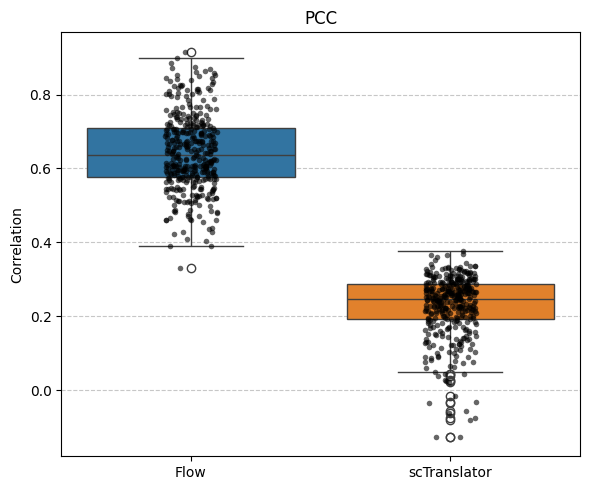

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# 直接把两组数据放到一个列表中
data_to_plot = [correlations_ours, correlations]
labels = ["Flow", "scTranslator"]

plt.figure(figsize=(6, 5))
sns.boxplot(data=data_to_plot)  # 直接传 list of lists
plt.xticks([0, 1], labels)      # 改 x 轴标签

# 可选：叠加散点来展示分布
for i, group in enumerate(data_to_plot):
    sns.stripplot(x=[i]*len(group), y=group, color='black', size=4, alpha=0.6)

plt.title("PCC")
plt.ylabel("Correlation")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

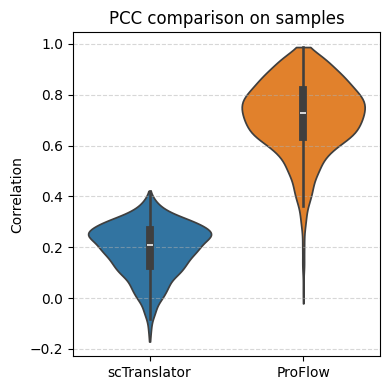

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42 

# 假设 correlations_ours 和 correlations 是列表或一维数组
data_to_plot = [corr_row, corr_row_ours]
labels = ["scTranslator", 'ProFlow']

plt.figure(figsize=(4, 4))  # 调窄一些
sns.violinplot(data=data_to_plot, inner="box", cut=0)  # 小提琴图，内嵌箱型
plt.xticks([0, 1], labels)

# # 叠加散点，让分布更清晰
# for i, group in enumerate(data_to_plot):
#     sns.stripplot(x=[i]*len(group), y=group, color='black', size=3, alpha=0.6)

plt.title("PCC comparison on samples")
plt.ylabel("Correlation")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("pcc_comparison_sample.pdf", format='pdf', bbox_inches='tight', transparent=True)
plt.show()

In [36]:
np.save('sctrans_corrs.npy', correlations)